# Compare cumulative energy & cumulative energy wake loss between SCADA, a dynamic model (LES) and FLORIS

In this notebook, we will demonstrate ...

In [30]:
from pathlib import Path

import numpy as np
import pandas as pd

from flasc.analysis import energy_ratio as er
from flasc.analysis.analysis_input import AnalysisInput
from flasc.data_processing import dataframe_manipulations as dfm
from flasc.data_processing import time_operations as tops
from flasc.utilities import floris_tools as ftools
from flasc.utilities.utilities_examples import load_floris_smarteole as load_floris

# Suppress warnings
import warnings
warnings.filterwarnings("ignore")

# Step 0: Specify user options, load FLORIS and define helper functions

In [31]:
# Specify which turbines to include/exclude. Since it's all baseline operation, we use all turbines.
include_turbs = [0, 1, 2, 3, 4, 5, 6]
exclude_turbs = []

# Load FLORIS model of site
fm, turbine_weights = load_floris()

# Use FLORIS to identify upstream / unwaked turbines for each direction
df_upstream = ftools.get_upstream_turbs_floris(fm)

# Introduce helper functions for calculating errors and generating plots/tables
def err(old_val, new_val):
    return 100.0 * (new_val-old_val) / old_val

# Introduce helper functions for calculating wake loss (%)
def wake_loss(aep_waked, aep_unwaked):
    return 100.0 * (aep_unwaked-aep_waked) / aep_unwaked

# A function to print table
def print_pretty_table(table_dict, title):
    # Format title to be centered above the table, and print table in pretty format
    df_table = pd.DataFrame(table_dict)
    mrkdwn = df_table.to_markdown(headers='keys', tablefmt='psql', index=False, floatfmt=".2f")
    spc = int(np.floor(len(mrkdwn.split("\n")[0]) / 2 - len(title) / 2))
    mrkdwn = (" " * spc + title + "\n") + mrkdwn
    return print(mrkdwn)

# Step 1: Load processed data

Load the processed SCADA data and assign reference wind directions, wind speeds and reference power productions by the upstream turbines

In [32]:
def load_data():
    root_path = Path.cwd()
    f = root_path / "postprocessed" / "df_scada_data_60s_filtered_and_northing_calibrated.pkl"
    df_scada = pd.read_pickle(f)

    return df_scada

# Load the data
df_scada = load_data()

# And calculate some helper variables
n_turbs = dfm.get_num_turbines(df_scada)
pow_cols = [f"pow_{ti:03d}" for ti in range(n_turbs)]
print(f"Number of turbines in dataset: {n_turbs}.")

# The SCADA data set contains alternating 1-hour periods with baseline or wake steering control.
# For these examples, we'll limit the data to baseline operation. 
df_scada = df_scada[df_scada.control_mode == "baseline"].reset_index(drop=True)

# Set the wind direction as the average of all turbine averages
df_scada = dfm.set_wd_by_turbines(df_scada, include_turbs)

# Set the wind speed to be the average of all upstream turbines
# (turbines not in a wake in a given direction)
# Except for SMV5
df_scada = dfm.set_ws_by_upstream_turbines(df_scada, df_upstream, exclude_turbs=exclude_turbs)

# Set the reference power to the average of all upstream turbines
# Except for SMV5
df_scada = dfm.set_pow_ref_by_upstream_turbines(df_scada, df_upstream, exclude_turbs=exclude_turbs)

# Determine number of turbines available at any given time
df_scada["n_turbs_available"] = list(n_turbs - df_scada[pow_cols].isna().sum(axis=1))

# Print information to console
print(df_scada)

Number of turbines in dataset: 7.
FlascDataFrame in FLASC format
                     time      pow_000      pow_001      pow_002     pow_003  \
0     2020-02-17 16:30:00  2023.746948  2045.376953  2031.724976         NaN   
1     2020-02-17 16:31:00  1959.036011  2050.572998  2034.890991         NaN   
2     2020-02-17 16:32:00  2053.658936  2032.191040  2011.870972         NaN   
3     2020-02-17 16:33:00  2044.296997  2060.478027  1995.057983         NaN   
4     2020-02-17 16:34:00  2058.281006  2042.703003  2031.723999         NaN   
...                   ...          ...          ...          ...         ...   
81949 2020-05-24 22:56:00   179.934006   157.003998   192.214996  188.412994   
81950 2020-05-24 22:57:00   181.414993   176.386002   191.845993  198.539993   
81951 2020-05-24 22:58:00   187.748001   181.809006   183.802994  179.539001   
81952 2020-05-24 22:59:00   175.552002   176.250000   183.923004  152.393005   
81953 2020-05-24 23:00:00   169.324997   179.944000   1

# Step 2: Now calculate FLORIS model predictions for the SCADA dataset

description...

In [33]:
# Grab a FLORIS solution and turn it into a timeseries
wake_model = "cc"
fn = Path.cwd() / "precalculated_floris_solutions" / "df_fi_approx_{:s}.ftr".format(wake_model)
if fn.is_file():
    df_fm_approx = pd.read_feather(fn)
else:
    raise UserWarning(
        "Please run '01_precalculate_floris_solutions.ipynb' "
        "for the appropriate wake models first."
    )

df_floris_timeseries = ftools.interpolate_floris_from_df_approx(
    df=df_scada, df_approx=df_fm_approx, method="linear", verbose=True
)
print(df_floris_timeseries)
df_floris_timeseries[pow_cols] *= 1.0e-3  # Scale results from [W] to [kW] in accordance to SCADA

2026-01-06 16:22:51 Identified the following grid type: 3d.
2026-01-06 16:22:51 Warning: the values in df[ws] exceed the range in the precalculated solutions df_fi_approx[ws].
2026-01-06 16:22:51    minimum/maximum value in df:        (0.250, 19.557)
2026-01-06 16:22:51    minimum/maximum value in df:        (0.250, 19.557)
2026-01-06 16:22:51    minimum/maximum value in df_approx: (1.000, 30.000)
2026-01-06 16:22:51 Mapping the precalculated solutions from FLORIS to the dataframe...
2026-01-06 16:22:51   Creating a gridded interpolant with interpolation method 'linear'.
2026-01-06 16:22:52      Interpolating pow for all turbines...
2026-01-06 16:22:52 Finished interpolation in 0.103 seconds.


FlascDataFrame in FLASC format
               wd         ws    ti                time       pow_000  \
0      251.377068  12.452667  0.11 2020-02-17 16:30:00  1.948538e+06   
1      251.485048  12.776333  0.11 2020-02-17 16:31:00  1.977804e+06   
2      253.473037  12.888800  0.11 2020-02-17 16:32:00  1.987973e+06   
3      251.104001  13.468800  0.11 2020-02-17 16:33:00  2.017250e+06   
4      255.679234  13.029600  0.11 2020-02-17 16:34:00  1.999241e+06   
...           ...        ...   ...                 ...           ...   
81949  306.282002   5.361714  0.11 2020-05-24 22:56:00  2.139622e+05   
81950  306.411418   5.309000  0.11 2020-05-24 22:57:00  2.058329e+05   
81951  308.109904   5.296286  0.11 2020-05-24 22:58:00  2.038721e+05   
81952  310.160703   5.219857  0.11 2020-05-24 22:59:00  1.920857e+05   
81953  310.323495   5.178714  0.11 2020-05-24 23:00:00  1.857408e+05   

            pow_001       pow_002        pow_003       pow_004       pow_005  \
0      1.948538e+06  1.9

In [34]:
########################################################################################################################################
###### Load LES timeseries in preparation for validation against SCADA. We will try various validation metrics and approaches... #######
########################################################################################################################################

# Grab the raw LES timeseries
df_les_timeseries_raw = pd.read_csv("data/SMARTEOLE-LES-simulation-data/les_timeseries.csv")
df_les_timeseries_raw["time"] = pd.to_datetime(df_les_timeseries_raw["time"])

# Fix scaling in LES from [W] to [kW]
df_les_timeseries_raw[pow_cols] *= 1.0e-3

# Assign freestream ambient conditions by the turbines
df_les_timeseries_raw = dfm.set_wd_by_turbines(df_les_timeseries_raw, include_turbs)
df_les_timeseries_raw = dfm.set_ws_by_upstream_turbines(df_les_timeseries_raw, df_upstream, exclude_turbs=exclude_turbs)
df_les_timeseries_raw = dfm.set_pow_ref_by_upstream_turbines(df_les_timeseries_raw, df_upstream, exclude_turbs=exclude_turbs)
df_les_timeseries_raw["ti"] = 0.10   # Placeholder assumption for TI

# Map raw LES directly to the SCADA timeseries using linear interpolation
df_les_raw_resampled = tops.df_resample_by_interpolation(
    df=df_les_timeseries_raw,
    time_array=pd.to_datetime(df_scada["time"]),
    circular_cols=[c for c in df_les_timeseries_raw.columns if c.startswith("wd")],
)

2026-01-06 16:22:53   Resampling column 'pow_000' with median timestep 600.012 s onto a prespecified time array with kind=linear, max_gap=90.0s, and wrap_around_360=False
2026-01-06 16:22:53   Resampling column 'pow_001' with median timestep 600.012 s onto a prespecified time array with kind=linear, max_gap=90.0s, and wrap_around_360=False
2026-01-06 16:22:53   Resampling column 'pow_002' with median timestep 600.012 s onto a prespecified time array with kind=linear, max_gap=90.0s, and wrap_around_360=False
2026-01-06 16:22:53   Resampling column 'pow_003' with median timestep 600.012 s onto a prespecified time array with kind=linear, max_gap=90.0s, and wrap_around_360=False
2026-01-06 16:22:53   Resampling column 'pow_004' with median timestep 600.012 s onto a prespecified time array with kind=linear, max_gap=90.0s, and wrap_around_360=False
2026-01-06 16:22:54   Resampling column 'pow_005' with median timestep 600.012 s onto a prespecified time array with kind=linear, max_gap=90.0s, 

# Step 3: Define helper function that calculates relevant AEP errors

Description...

In [35]:
def compare_absolute_aep_and_relative_wake_loss(df_scada, df_model_list, model_tags=None, print_values=True, print_errors=True):
    # Input formatting options
    if isinstance(df_model_list, pd.DataFrame):
        df_model_list = [df_model_list]

    if model_tags is None:
        model_tags = [f"Model {ti}" for ti in range(len(df_model_list))]

    # Specify a unit conversion
    unit_conversion = 1.0e-3 * np.nanmedian(df_scada["time"].diff()) / np.timedelta64(3600, 's')  # From sum of samples to MWh

    # Make local copies of dataframes that we can manipulate
    df_scada = df_scada.copy()
    df_model_list = [df.copy() for df in df_model_list]

    # First ensure consistent NaN mapping between modelled data and SCADA
    n_turbs = dfm.get_num_turbines(df_scada)
    for ti in range(n_turbs):
        ids_nan = df_scada[f"pow_{ti:03d}"].isna()
        for df_model in df_model_list:
            ids_nan = ids_nan | df_model[f"pow_{ti:03d}"].isna()
        ids_nan = np.where(ids_nan)[0]

        # Mirror NaNs across all model predictions and SCADA
        df_scada.loc[ids_nan, f"pow_{ti:03d}"] = None
        for df_model in df_model_list:
            df_model.loc[ids_nan, f"pow_{ti:03d}"] = None

    # Assert NaNs are identical between dataframes
    n_scada = df_scada[pow_cols].isna().sum().sum()
    n_models = [
        df_model[pow_cols].isna().sum().sum()
        for df_model in df_model_list
    ]
    print(f"NaNs in df_scada power columns: {n_scada}")
    print(f"NaNs in df_models power columns: {n_models}")

    for df_model in df_model_list:
        # Specify upstream power in the exact same way as with the SCADA data
        df_model = dfm.set_pow_ref_by_upstream_turbines(df_model, df_upstream, exclude_turbs=exclude_turbs)

        # Determine number of turbines available at any given time, similar to SCADA
        df_model["n_turbs_available"] = (~df_model[pow_cols].isna()).sum(axis=1)

    # # Assert that number of turbines available at each timestamp is identical between SCADA and LES simulation
    # all(df_model_list[0]["n_turbs_available"] == df_scada["n_turbs_available"])

    #######################################################################################################################
    ################## Compare absolute AEP directly between SCADA and simulated data (LES) ###############################
    #######################################################################################################################

    # Absolute AEP for the entire farm and per turbine
    aep_turbine_scada = [df_scada[pc].sum() * unit_conversion for pc in pow_cols]
    aep_turbine_models = [
        [df_model[pc].sum() * unit_conversion for pc in pow_cols]
        for df_model in df_model_list
    ]
    aep_farm_scada = np.sum(aep_turbine_scada)
    aep_farm_models = [np.sum(aep_tm) for aep_tm in aep_turbine_models]

    table_absolute_aep_dict = {
        "Selection": ["Entire farm"] + [f"Turbine {ti:02d}" for ti in range(n_turbs)],
        "SCADA (MWh)": [aep_farm_scada] + aep_turbine_scada,
    }
    for mii, model_tag in enumerate(model_tags):
        if print_values:
            table_absolute_aep_dict[f"{model_tag} (MWh)"] = [aep_farm_models[mii]] + aep_turbine_models[mii]
        if print_errors:
            table_absolute_aep_dict[f"{model_tag} error (%)"] = (
                [err(aep_farm_scada, aep_farm_models[mii])] +
                [err(x, y) for x, y in zip(aep_turbine_scada, aep_turbine_models[mii])]
            )

    print_pretty_table(table_absolute_aep_dict, title="Absolute cumulative energy (MWh)")
    print("\n")

    #######################################################################################################################
    ################ Now we do the same exercise, but with wake loss rather than absolute AEP #############################
    #######################################################################################################################

    # Compare AEP wake loss relative to most upstream turbines
    aep_turbine_scada_waked = np.array([None for _ in range(n_turbs)], dtype=float)
    aep_turbine_scada_unwaked = np.array([None for _ in range(n_turbs)], dtype=float)
    aep_turbine_models_waked = [np.array([None for _ in range(n_turbs)], dtype=float) for _ in df_model_list]
    aep_turbine_models_unwaked = [np.array([None for _ in range(n_turbs)], dtype=float) for _ in df_model_list]

    for ti in range(n_turbs):
        # First SCADA
        p_test = np.array(df_scada[f"pow_{ti:03d}"], dtype=float, copy=True)
        p_ref = np.array(df_scada["pow_ref"], dtype=float, copy=True)
        ids_non_nan = (~np.isnan(p_test)) & (~np.isnan(p_ref))
        aep_turbine_scada_unwaked[ti] = np.sum(p_ref[ids_non_nan]) * unit_conversion
        aep_turbine_scada_waked[ti] = np.sum(p_test[ids_non_nan]) * unit_conversion

        # Now LES and FLORIS
        for dii, df_model in enumerate(df_model_list):
            p_test = np.array(df_model[f"pow_{ti:03d}"], dtype=float, copy=True)
            p_ref = np.array(df_model["pow_ref"], dtype=float, copy=True)
            ids_non_nan = (~np.isnan(p_test)) & (~np.isnan(p_ref))
            aep_turbine_models_unwaked[dii][ti] = np.sum(p_ref[ids_non_nan]) * unit_conversion
            aep_turbine_models_waked[dii][ti] = np.sum(p_test[ids_non_nan]) * unit_conversion

    aep_farm_scada_waked = np.sum(aep_turbine_scada_waked)
    aep_farm_scada_unwaked = np.sum(aep_turbine_scada_unwaked)
    aep_farm_models_waked = [np.sum(aep_tm_waked) for aep_tm_waked in aep_turbine_models_waked]
    aep_farm_models_unwaked = [np.sum(aep_tm_unwaked) for aep_tm_unwaked in aep_turbine_models_unwaked]

    # Derive wake loss percentages and errors, and print as a pretty table
    wake_losses_scada = np.hstack(
        [
            wake_loss(aep_farm_scada_waked, aep_farm_scada_unwaked),
            wake_loss(aep_turbine_scada_waked, aep_turbine_scada_unwaked)
        ]
    )
    wake_losses_models = [
            np.hstack(
            [
                wake_loss(aep_farm_models_waked[dii], aep_farm_models_unwaked[dii]),
                wake_loss(aep_turbine_models_waked[dii], aep_turbine_models_unwaked[dii])
            ]
        )
        for dii in range(len(df_model_list))
    ]

    table_wakeloss_aep_dict = {
        "Selection": ["Entire farm"] + [f"Turbine {ti:02d}" for ti in range(n_turbs)],
        "SCADA (%)": wake_losses_scada
    }
    for mii, model_tag in enumerate(model_tags):
        if print_values:
            table_wakeloss_aep_dict[f"{model_tag} (%)"] = wake_losses_models[mii]
        if print_errors:
            table_wakeloss_aep_dict[f"{model_tag} error (p.p.)"] = wake_losses_models[mii] - wake_losses_scada

    print_pretty_table(table_wakeloss_aep_dict, title="Cumulative energy wake loss (%)")

    return table_absolute_aep_dict, table_wakeloss_aep_dict

# Option for validation 1: compare the two timeseries directly, assuming (hoping) that LES predicted the inflow conditions accurately.

For this, we must ensure the NaNs in the SCADA also appear as NaNs in the LES timeseries. Assuming the same timezone format...

In [36]:
# Now being on the same timeseries, map NaNs from SCADA to LES
df_les = df_les_raw_resampled.copy()

# Perform comparison using this LES dataframe
table_absolute_aep_dict, table_wakeloss_aep_dict = compare_absolute_aep_and_relative_wake_loss(
    df_scada,
    [df_les, df_floris_timeseries],
    model_tags=["LES", "FLORIS CC"]
)

NaNs in df_scada power columns: 457712
NaNs in df_models power columns: [np.int64(457712), np.int64(457712)]
                                     Absolute cumulative energy (MWh)
+-------------+---------------+-------------+-----------------+-------------------+-----------------------+
| Selection   |   SCADA (MWh) |   LES (MWh) |   LES error (%) |   FLORIS CC (MWh) |   FLORIS CC error (%) |
|-------------+---------------+-------------+-----------------+-------------------+-----------------------|
| Entire farm |       1355.41 |     1287.20 |           -5.03 |           1324.38 |                 -2.29 |
| Turbine 00  |        219.83 |      210.66 |           -4.17 |            207.10 |                 -5.79 |
| Turbine 01  |        196.56 |      184.18 |           -6.30 |            187.31 |                 -4.71 |
| Turbine 02  |        188.43 |      171.55 |           -8.96 |            180.33 |                 -4.30 |
| Turbine 03  |        168.75 |      153.86 |           -8.82 |  

# Option for validation 2: we re-map the LES timeseries onto the SCADA ambient wind directions and wind speeds. 

This ensures the ambient conditions are identical between the two datasets. We do this by turning the LES simulation into a steady-state table of solutions, basically identical to a FLORIS solutions table.

No circular columns specified. Automatically identified: ['wd_000', 'wd_001', 'wd_002', 'wd_003', 'wd_004', 'wd_005', 'wd_006'].
Applying regular averaging on entire dataframe (29 columns).
Applying circular averaging on 7 columns.
Flagged an additional 36 table entries as NaN because their sample pool is smaller than 3 (N_min).


2026-01-06 16:22:59 Identified the following grid type: 2d.
2026-01-06 16:22:59 Warning: the values in df[wd] exceed the range in the precalculated solutions df_fi_approx[wd].
2026-01-06 16:22:59    minimum/maximum value in df:        (0.035, 359.955)
2026-01-06 16:22:59    minimum/maximum value in df:        (0.035, 359.955)
2026-01-06 16:22:59    minimum/maximum value in df_approx: (0.000, 355.000)
2026-01-06 16:22:59 Warning: the values in df[ws] exceed the range in the precalculated solutions df_fi_approx[ws].
2026-01-06 16:22:59    minimum/maximum value in df:        (0.250, 19.557)
2026-01-06 16:22:59    minimum/maximum value in df:        (0.250, 19.557)
2026-01-06 16:22:59    minimum/maximum value in df_approx: (4.000, 18.000)
2026-01-06 16:22:59 Warning: the values in df[ti] exceed the range in the precalculated solutions df_fi_approx[ti].
2026-01-06 16:22:59    minimum/maximum value in df:        (0.110, 0.110)
2026-01-06 16:22:59    minimum/maximum value in df:        (0.110

Approximate table contains 505 valid entries (46.76%) and 575 invalid entries (53.24%).
         wd    ws   ti      wd_000      wd_001      wd_002     wd_003  \
0       0.0   4.0  0.5  358.867189  359.404097  359.077879   1.173013   
1       5.0   4.0  0.5    5.823989    6.555070    6.083463   9.914013   
2      10.0   4.0  0.5    8.194114    8.930340    9.225630  13.631851   
3      15.0   4.0  0.5   14.062022   14.001720   13.536481  16.904732   
4      20.0   4.0  0.5   18.492192   18.545229   17.918692  20.567461   
...     ...   ...  ...         ...         ...         ...        ...   
1075  335.0  18.0  NaN         NaN         NaN         NaN        NaN   
1076  340.0  18.0  NaN         NaN         NaN         NaN        NaN   
1077  345.0  18.0  NaN         NaN         NaN         NaN        NaN   
1078  350.0  18.0  NaN         NaN         NaN         NaN        NaN   
1079  355.0  18.0  NaN         NaN         NaN         NaN        NaN   

         wd_004      wd_005     wd_

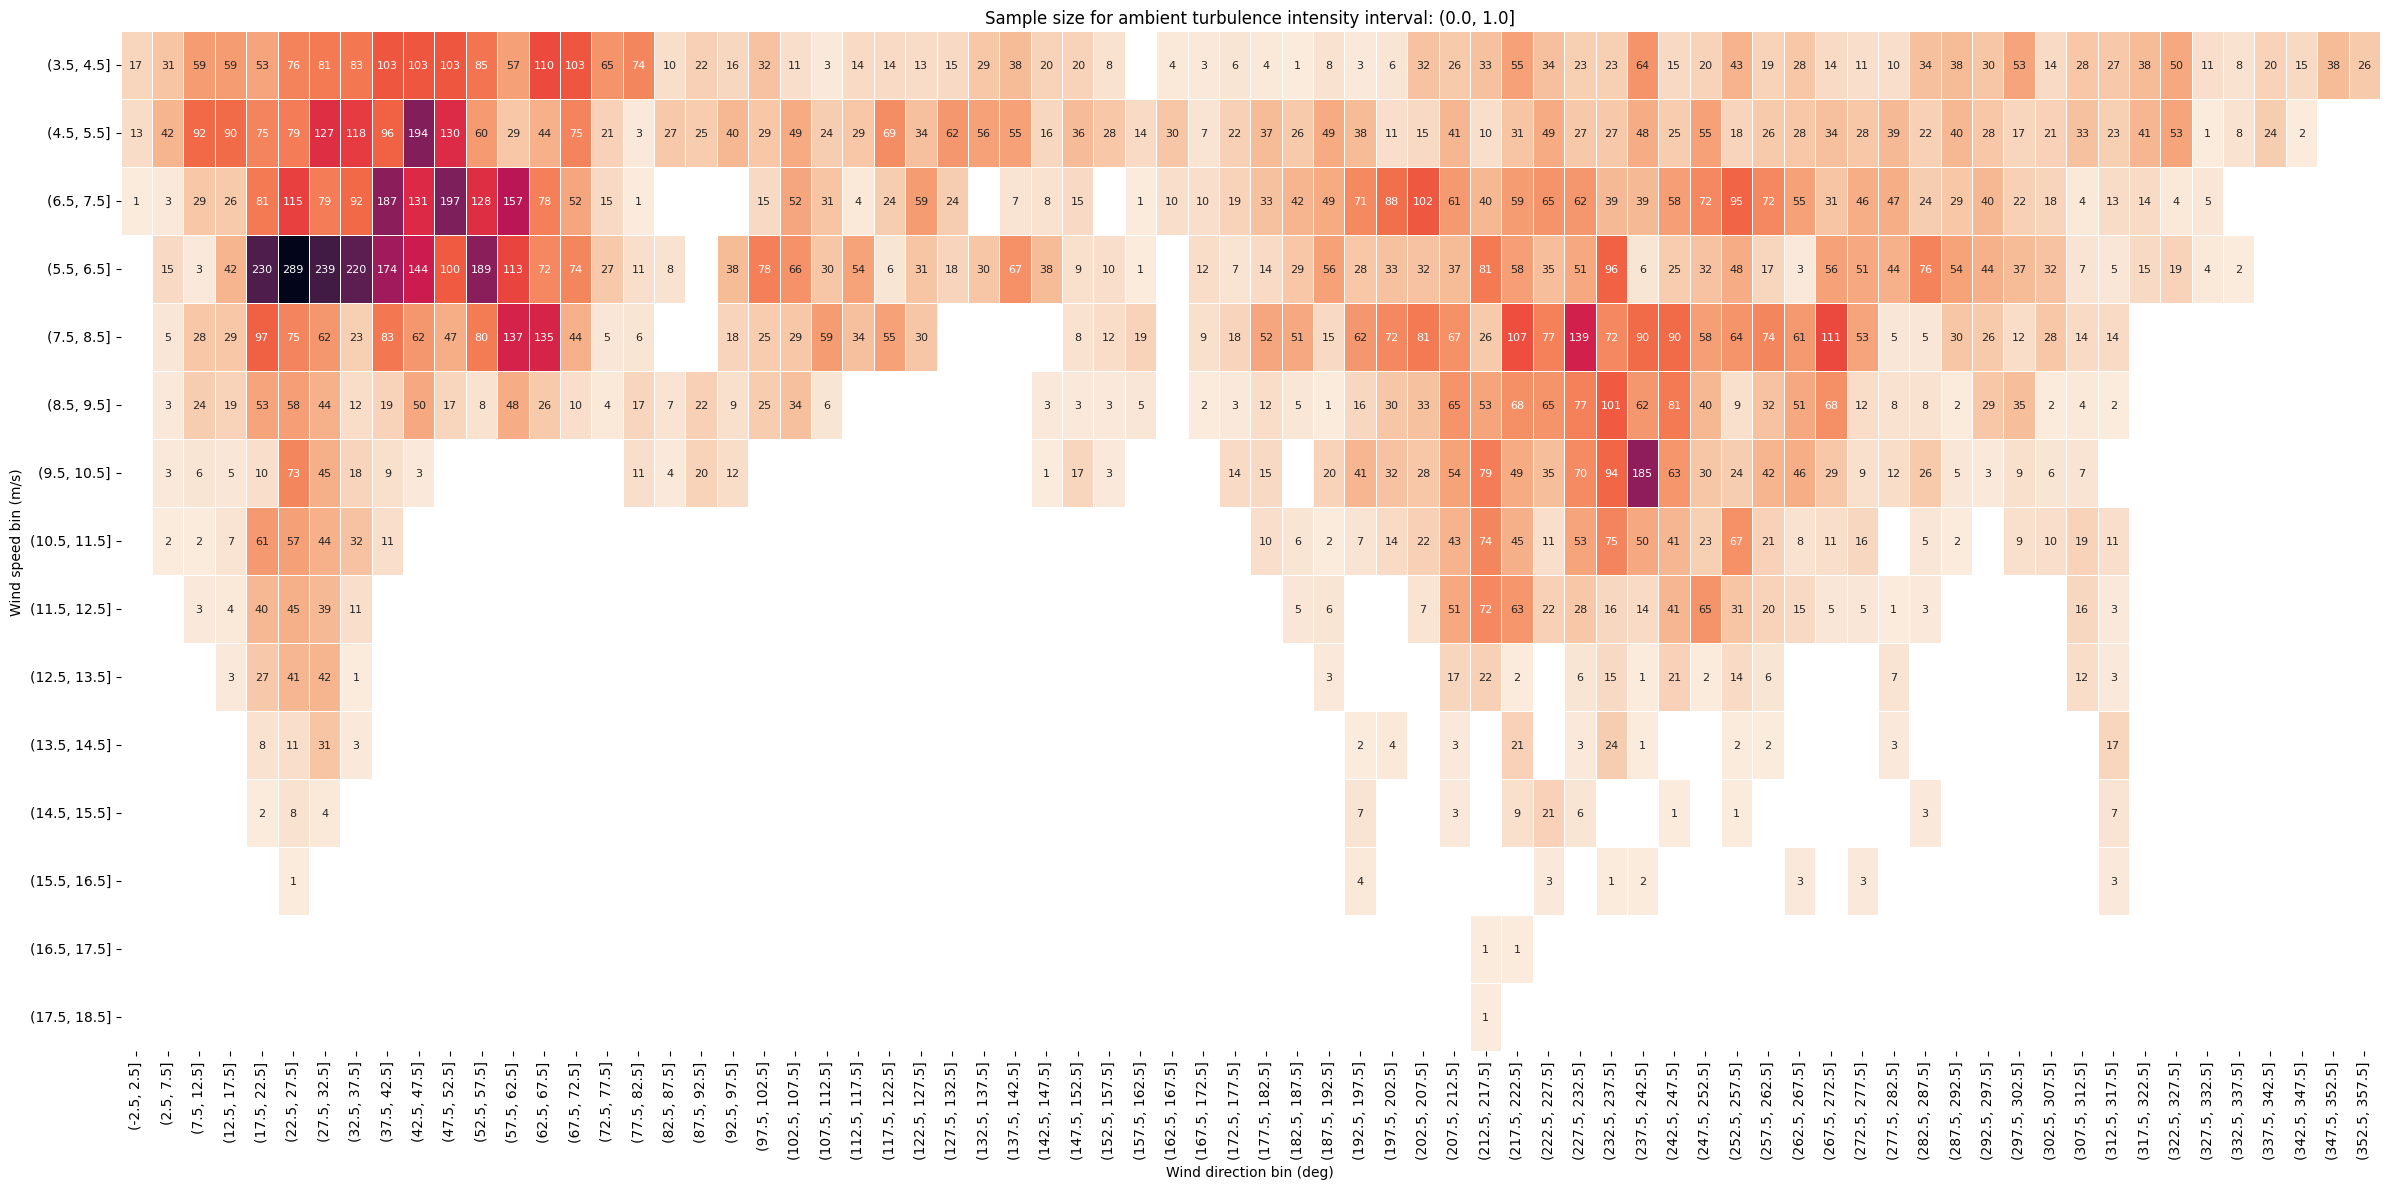

In [37]:
# # We start with the original timeseries, mapped onto the same time vector as the SCADA
df_les = df_les_raw_resampled.copy()

# Load the timeseries dataframe into the class
from flasc.data_processing.timeseries_to_grid_solutions import ConvertTimeseriesToSolutionGrid
g = ConvertTimeseriesToSolutionGrid(df_timeseries=df_les)

# Bin the LES data by wind directions and wind speeds (for now: not by TI)
df_binned = g.bin_timeseries(
    wd_step=5.0,
    ws_array=np.arange(3.5, np.ceil(df_fm_approx["ws"].max()) + 0.01, 1.0),
    ti_array=[0.0, 1.0],  # Pour everything into a single TI bin
    circular_cols=None,
    plot=True,
    verbose=True
)

# Convert the binned data into the right formatting matching those of df_fm_approx
df_les_steadystate_table = g.convert_binned_dataframe_to_df_fi_approx(N_min=3)  # At least 3 valid samples

# Use this steady-state table to produce a new timeseries with identical inflow as SCADA
df_les_timeseries_inflowremapped = ftools.interpolate_floris_from_df_approx(
    df=df_scada, df_approx=df_les_steadystate_table, method="linear", verbose=True
)

print(df_les_steadystate_table)

## Next, we can compare this inflow-remapped timeseries directly to SCADA. This may change the absolute AEP errors substantially, but likely will leave the relative wake loss percentages mostly intact.

In [38]:
# Perform comparison using this inflow-remapped LES dataframe
table_absolute_aep_dict, table_wakeloss_aep_dict = compare_absolute_aep_and_relative_wake_loss(
    df_scada,
    [df_les, df_les_timeseries_inflowremapped, df_floris_timeseries],
    model_tags=["LES (original inflow)", "LES (inflow-remapped)", "FLORIS CC"],
    print_values=True,
    print_errors=False
)

NaNs in df_scada power columns: 476293
NaNs in df_models power columns: [np.int64(476293), np.int64(476293), np.int64(476293)]
                                         Absolute cumulative energy (MWh)
+-------------+---------------+-------------------------------+-------------------------------+-------------------+
| Selection   |   SCADA (MWh) |   LES (original inflow) (MWh) |   LES (inflow-remapped) (MWh) |   FLORIS CC (MWh) |
|-------------+---------------+-------------------------------+-------------------------------+-------------------|
| Entire farm |        948.90 |                        939.61 |                       1050.00 |            925.80 |
| Turbine 00  |        155.87 |                        155.15 |                        172.45 |            145.77 |
| Turbine 01  |        143.00 |                        139.20 |                        155.69 |            135.72 |
| Turbine 02  |        130.48 |                        122.36 |                        137.44 |        

Calculating energy ratios with bootstrapping (N=20).
This may take a couple seconds...


Text(0.5, 1.0, 'Energy Ratios for turbines [0, 1, 2, 3, 4, 5, 6]')

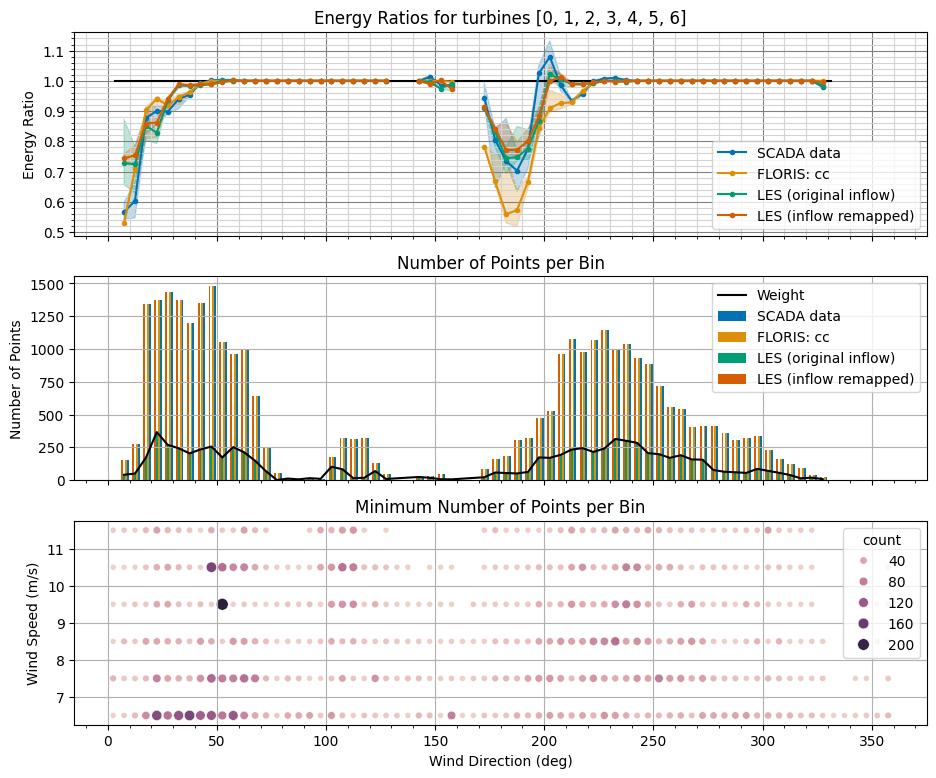

In [39]:
# Let's also look at an energy ratio, for good measure

# Specify upstream turbines in same fashion as for the SCADA data
df_les_timeseries_raw = dfm.set_pow_ref_by_upstream_turbines(df_les_timeseries_raw, df_upstream, exclude_turbs=exclude_turbs)
df_les_timeseries_inflowremapped = dfm.set_pow_ref_by_upstream_turbines(df_les_timeseries_inflowremapped, df_upstream, exclude_turbs=exclude_turbs)
df_floris_timeseries = dfm.set_pow_ref_by_upstream_turbines(df_floris_timeseries, df_upstream, exclude_turbs=exclude_turbs)

# Initialize energy ratio analysis class and perform common operations. E.g., let's look at turbine 4.
a_in = AnalysisInput(
    [df_scada, df_floris_timeseries, df_les_timeseries_raw, df_les_timeseries_inflowremapped],
    ["SCADA data", f"FLORIS: {wake_model}", "LES (original inflow)", "LES (inflow remapped)"]
)

N = 20
print("Calculating energy ratios with bootstrapping (N={}).".format(N))
print("This may take a couple seconds...")
np.random.seed(0)
er_out = er.compute_energy_ratio(
    a_in,
    test_turbines=include_turbs,
    use_predefined_ref=True,
    use_predefined_wd=True,
    use_predefined_ws=True,
    wd_step=5.0,
    wd_bin_overlap_radius=0.0,
    ws_min=6.0,
    ws_max=12.0,
    N=N,
    percentiles=[5.0, 95.0],
)
ax = er_out.plot_energy_ratios(overlay_frequency=True)
ax[0].set_title(f"Energy Ratios for turbines {include_turbs}")

Calculating energy ratios with bootstrapping (N=20).
This may take a couple seconds...


Text(0.5, 1.0, 'Energy Ratios for turbines [0, 1, 2, 3, 4, 5, 6]')

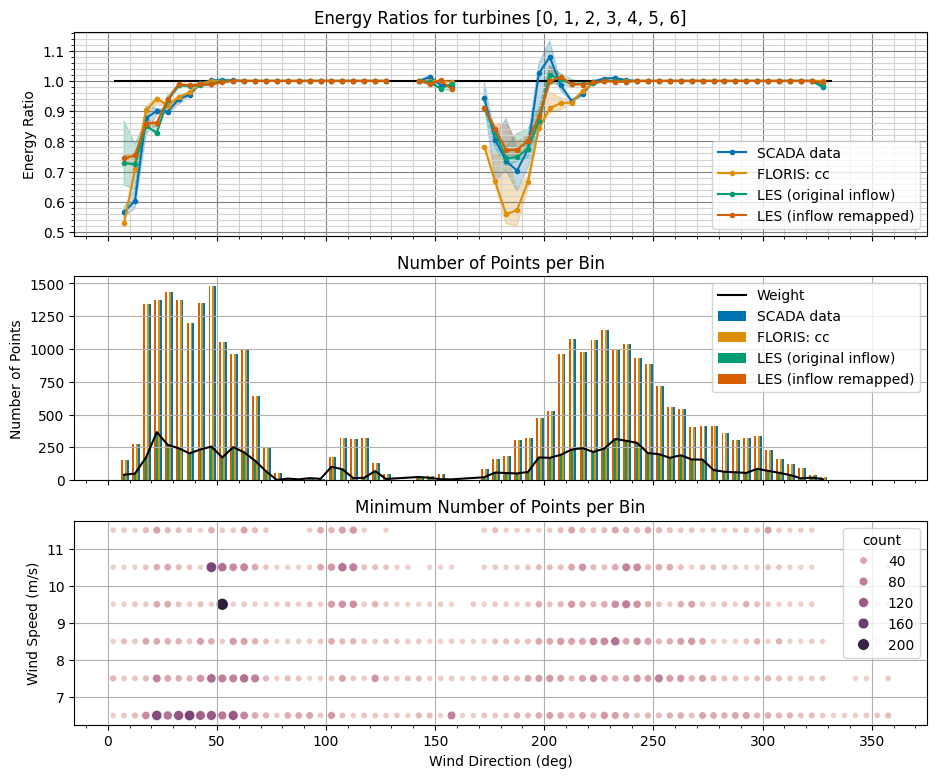

In [40]:
# Now re-do everything while enforcing same frequency distribution as SCADA.
# Q: Why does this not cause green and orange lines to collapse to the same?

# df_freq variable is based on the first entry (here: SCADA)
df_freq = er_out.df_freq
df_freq = df_freq.rename(columns={"wd_bin": "wd", "ws_bin": "ws", "weight": "freq_val"})

# Now replot everything with this df_freq
N = 20
print("Calculating energy ratios with bootstrapping (N={}).".format(N))
print("This may take a couple seconds...")
np.random.seed(0)
er_out = er.compute_energy_ratio(
    a_in,
    test_turbines=include_turbs,
    use_predefined_ref=True,
    use_predefined_wd=True,
    use_predefined_ws=True,
    wd_step=5.0,
    wd_bin_overlap_radius=0.0,
    ws_min=6.0,
    ws_max=12.0,
    N=N,
    percentiles=[5.0, 95.0],
    df_freq=df_freq
)
ax = er_out.plot_energy_ratios(overlay_frequency=True)
ax[0].set_title(f"Energy Ratios for turbines {include_turbs}")